In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    display(x)


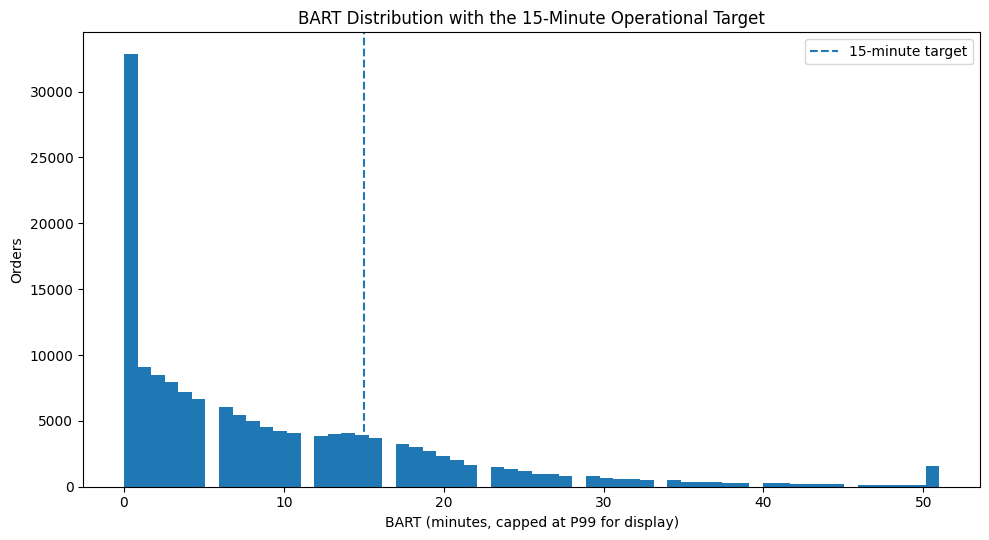

In [2]:
valid = main["BART_min"].dropna()
cap = valid.quantile(0.99)
fig, ax = plt.subplots(figsize=(10,5.5))
ax.hist(valid.clip(upper=cap), bins=60)
ax.axvline(15, linestyle="--", linewidth=1.5, label="15-minute target")
ax.set_title("BART Distribution with the 15-Minute Operational Target")
ax.set_xlabel("BART (minutes, capped at P99 for display)")
ax.set_ylabel("Orders")
ax.legend()
savefig("F01_BART_Distribution_and_Target.png")


In [3]:
late = main.loc[main["BART_min"]>15, "BART_min"]-15
late_trim = late[late<=late.quantile(.99)]
kpi = pd.DataFrame({
    "KPI":["BART15","ALM15 raw","ALM15 robust P99-trimmed","Acceptance P90","Delayed Offer Rate","Arrival P90"],
    "Current":[main["BART15"].mean()*100, late.mean(), late_trim.mean(), seq["Acceptance_min"].quantile(.9), main.loc[main["order_offer_badge"].notna(),"delayed_flag"].mean()*100, seq["Arrival_min"].quantile(.9)],
    "Operational reference":[">= 90%","<= 11 min","<= 11 min","<= 8 min","<= 5%","<= 10 min"]
})
save_table(kpi,"T01_KPI_Snapshot_and_Thresholds.png")


,KPI,Current,Operational reference
0,BART15,77.45,>= 90%
1,ALM15 raw,14.29,<= 11 min
2,ALM15 robust P99-trimmed,10.09,<= 11 min
3,Acceptance P90,14.00,<= 8 min
4,Delayed Offer Rate,16.35,<= 5%
5,Arrival P90,12.00,<= 10 min


In [4]:
quality = pd.DataFrame({
    "Data-quality item":["Merged orders","Valid BART orders Aug-Oct","Sequential timestamp cohort","Sequential cohort coverage","arrived_pickup_at before accept_time","Missing start_time_slot","Missing accept_time","Missing biker"],
    "Value":[len(df),len(main),len(seq),len(seq)/len(main)*100,((main["arrived_pickup_at"]<main["accept_time"]).sum()),df["start_time_slot"].isna().sum(),df["accept_time"].isna().sum(),df["biker"].isna().sum()]
})
save_table(quality,"T02_Data_Quality_Summary.png")


,Data-quality item,Value
0,Merged orders,151803.00
1,Valid BART orders Aug-Oct,151580.00
2,Sequential timestamp cohort,127774.00
3,Sequential cohort coverage,84.29
4,arrived_pickup_at before accept_time,23803.00
5,Missing start_time_slot,221.00
6,Missing accept_time,224.00
7,Missing biker,16.00


In [5]:
all_cells = main.groupby(["order_city","hour_bucket"]).agg(Orders=("order_id","size"),BART15=("BART15","mean"),DOR=("delayed_flag","mean")).reset_index()
all_cells = all_cells[all_cells["Orders"]>=20]
healthy_all = all_cells[all_cells["BART15"]>=.90]
seq_cells = seq.groupby(["order_city","hour_bucket"]).agg(Orders=("order_id","size"),BART15=("BART15","mean"),Acceptance_P90=("Acceptance_min",lambda s:s.quantile(.9)),Arrival_P90=("Arrival_min",lambda s:s.quantile(.9))).reset_index()
seq_cells = seq_cells[seq_cells["Orders"]>=20]
healthy_seq = seq_cells[seq_cells["BART15"]>=.90]
thresholds = pd.DataFrame({
    "Metric":["Acceptance P90","Arrival P90","Delayed Offer Rate"],
    "Healthy median":[healthy_seq["Acceptance_P90"].median(),healthy_seq["Arrival_P90"].median(),healthy_all["DOR"].median()*100],
    "Healthy P75":[healthy_seq["Acceptance_P90"].quantile(.75),healthy_seq["Arrival_P90"].quantile(.75),healthy_all["DOR"].quantile(.75)*100],
    "Healthy P90":[healthy_seq["Acceptance_P90"].quantile(.90),healthy_seq["Arrival_P90"].quantile(.90),healthy_all["DOR"].quantile(.90)*100],
    "Selected warning":[8,10,5],
    "Unit":["min","min","%"]
})
save_table(thresholds,"T03_Healthy_Period_Threshold_Basis.png")


,Metric,Healthy median,Healthy P75,Healthy P90,Selected warning,Unit
0,Acceptance P90,6.0,8.10,10.00,8,min
1,Arrival P90,8.3,9.80,10.97,10,min
2,Delayed Offer Rate,0.0,4.42,7.14,5,%
